# Preprocessing

### Merging the True.csv and Fake.csv of ISOT in to one
#### Label assigned as 0 = Real and 1 = Fake

In [2]:
import pandas as pd
import os

def merge_and_shuffle_isot(true_csv_path, fake_csv_path, output_directory):
    print("⏳ Loading ISOT True and Fake datasets...")

    # ================================================================
    # 1. CHECK FILES
    # ================================================================
    if not os.path.exists(true_csv_path):
        raise FileNotFoundError(f"Could not find True.csv at: {true_csv_path}")

    if not os.path.exists(fake_csv_path):
        raise FileNotFoundError(f"Could not find Fake.csv at: {fake_csv_path}")

    # ================================================================
    # 2. LOAD BOTH DATASETS
    # ================================================================
    df_true = pd.read_csv(true_csv_path)
    df_fake = pd.read_csv(fake_csv_path)

    print(f"True.csv: {len(df_true):,} rows")
    print(f"Fake.csv: {len(df_fake):,} rows")

    # ================================================================
    # 3. KEEP ONLY TITLE AND TEXT
    #    This removes subject and date
    # ================================================================
    df_true = df_true[['title', 'text']].copy()
    df_fake = df_fake[['title', 'text']].copy()

    # Remove rows with missing title or text
    df_true = df_true.dropna(subset=['title', 'text'])
    df_fake = df_fake.dropna(subset=['title', 'text'])

    # ================================================================
    # 4. ADD LABELS
    # ================================================================
    # 0 = REAL NEWS
    # 1 = FAKE NEWS

    df_true['label'] = 0
    df_fake['label'] = 1

    # ================================================================
    # 5. COMBINE ALL DATA
    #    NO SAMPLING / NO BALANCING
    # ================================================================
    df_isot_master = pd.concat(
        [df_true, df_fake],
        ignore_index=True
    )

    print("\n📊 Before shuffling:")
    print(f"Real News (0): {len(df_true):,}")
    print(f"Fake News (1): {len(df_fake):,}")
    print(f"Total:         {len(df_isot_master):,}")

    # ================================================================
    # 6. RANDOMLY MIX ALL ROWS
    # ================================================================
    df_isot_master = df_isot_master.sample(
        frac=1.0,
        random_state=42
    ).reset_index(drop=True)

    # ================================================================
    # 7. FINAL COLUMN ORDER
    # ================================================================
    df_isot_master = df_isot_master[['title', 'text', 'label']]

    # ================================================================
    # 8. VERIFY
    # ================================================================
    print("\n" + "=" * 60)
    print("✓ ISOT MASTER DATASET CREATED")
    print("=" * 60)

    print(f"Total Rows:    {len(df_isot_master):,}")
    print(f"Real News (0): {(df_isot_master['label'] == 0).sum():,}")
    print(f"Fake News (1): {(df_isot_master['label'] == 1).sum():,}")

    print("\nColumns:")
    print(df_isot_master.columns.tolist())

    print("\nFirst 10 rows:")
    print(df_isot_master.head(10))

    print("\nLabel distribution:")
    print(df_isot_master['label'].value_counts())

    # ================================================================
    # 9. SAVE
    # ================================================================
    os.makedirs(output_directory, exist_ok=True)

    output_path = os.path.join(
        output_directory,
        "isot_master_clean.csv"
    )

    df_isot_master.to_csv(
        output_path,
        index=False
    )

    print("\n🚀 Complete dataset saved to:")
    print(output_path)


# ====================================================================
# FILE PATHS
# ====================================================================

local_true = r"C:\Users\yosef\fakemodel\datasets\True.csv"
local_fake = r"C:\Users\yosef\fakemodel\datasets\Fake.csv"

target_dir = r"C:\Users\yosef\fakemodel\datasets"


# ====================================================================
# RUN
# ====================================================================

merge_and_shuffle_isot(
    true_csv_path=local_true,
    fake_csv_path=local_fake,
    output_directory=target_dir
)

⏳ Loading ISOT True and Fake datasets...
True.csv: 21,417 rows
Fake.csv: 23,481 rows

📊 Before shuffling:
Real News (0): 21,417
Fake News (1): 23,481
Total:         44,898

✓ ISOT MASTER DATASET CREATED
Total Rows:    44,898
Real News (0): 21,417
Fake News (1): 23,481

Columns:
['title', 'text', 'label']

First 10 rows:
                                               title  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   
2   Mike Pence's New DC Neighbors Are HILARIOUSLY...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   
5  As private lawyer, Trump high court pick was f...   
6       Yemeni Salafist imam killed in Aden: sources   
7  FBI says witnesses in U.S. probe into Malaysia...   
8  An Easy To Read Chart Shows How Bernie Sanders...   
9  MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...   

                                                text  label  

# Describing the Data

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

# Path to your existing dataset
path = r"C:\Users\yosef\fakemodel\datasets\isot_master_clean.csv"

# Load dataset
df = pd.read_csv(path)

# Handle missing values
df['title'] = df['title'].fillna('').astype(str)
df['text'] = df['text'].fillna('').astype(str)

# Merge title + text into one column
# This changes only the current DataFrame, NOT the CSV file
df['content'] = df['title'] + ' ' + df['text']

# Preview
df.head()

,title,text,label,content
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",1,BREAKING: GOP Chairman Grassley Has Had Enoug...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,1,Failed GOP Candidates Remembered In Hilarious...
2,Mike Pence's New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,1,Mike Pence's New DC Neighbors Are HILARIOUSLY...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,0,California AG pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,1,AZ RANCHERS Living On US-Mexico Border Destroy...


In [4]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df[['title', 'text', 'content', 'label']].isnull().sum())

print("\nLabel counts:")
print(df['label'].value_counts())

Dataset shape: (44898, 4)

Columns:
['title', 'text', 'label', 'content']

Missing values:
title      0
text       0
content    0
label      0
dtype: int64

Label counts:
label
1    23481
0    21417
Name: count, dtype: int64


In [5]:
label_percentage = df['label'].value_counts(normalize=True) * 100

print(label_percentage)

label
1    52.298543
0    47.701457
Name: proportion, dtype: float64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate content:", df['content'].duplicated().sum())

Duplicate rows: 5794
Duplicate content: 5794


In [7]:
duplicates = df[df['content'].duplicated(keep=False)].sort_values('content')

duplicates[['content', 'label']].head(20)

,content,label
3487,#AnyoneButHillary: NEW POLL Shows Bernie Suppo...,1
3828,#AnyoneButHillary: NEW POLL Shows Bernie Suppo...,1
184,#Austin: Fights Break Out Between Police and S...,1
21075,#Austin: Fights Break Out Between Police and S...,1
7239,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,1
31596,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,1
36967,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,1
39783,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,1
3997,#BlackLivesMatter Supporters Say No Connection...,1
34422,#BlackLivesMatter Supporters Say No Connection...,1


In [8]:
df['word_count'] = df['content'].str.split().str.len()

df['word_count'].describe()

count    44898.000000
mean       417.735757
std        351.480777
min          2.000000
25%        216.000000
50%        375.000000
75%        526.000000
max       8148.000000
Name: word_count, dtype: float64

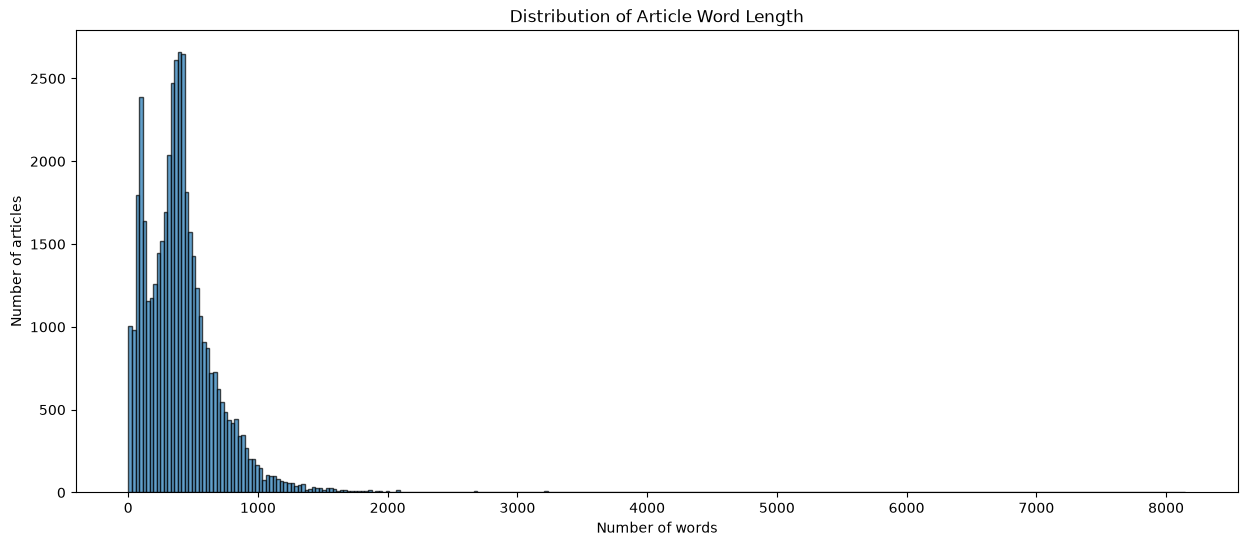

In [9]:
plt.figure(figsize=(15, 6))

plt.hist(
    df['word_count'],
    bins=300,              # More bars
    edgecolor='black',
    alpha=0.7,
    rwidth=15             # Width of each bar
)

plt.xlabel('Number of words')
plt.ylabel('Number of articles')
plt.title('Distribution of Article Word Length')

plt.show()

Mean (μ): 417.74
Standard deviation (σ): 351.48


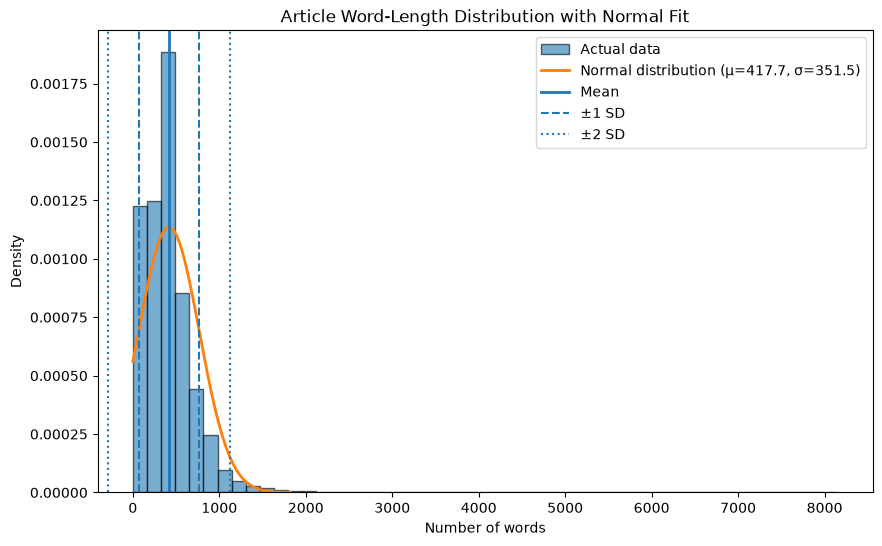

In [10]:
from scipy.stats import norm

# Mean and standard deviation
mu = df['word_count'].mean()
sigma = df['word_count'].std()

print(f"Mean (μ): {mu:.2f}")
print(f"Standard deviation (σ): {sigma:.2f}")

# Create x values
x = np.linspace(
    max(0, mu - 4 * sigma),
    mu + 4 * sigma,
    500
)

# Normal distribution
normal_curve = norm.pdf(x, mu, sigma)

# Plot
plt.figure(figsize=(10, 6))

plt.hist(
    df['word_count'],
    bins=50,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='Actual data'
)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label=f'Normal distribution (μ={mu:.1f}, σ={sigma:.1f})'
)

# Mean
plt.axvline(
    mu,
    linestyle='-',
    linewidth=2,
    label='Mean'
)

# ±1 standard deviation
plt.axvline(
    mu - sigma,
    linestyle='--',
    linewidth=1.5,
    label='±1 SD'
)

plt.axvline(
    mu + sigma,
    linestyle='--',
    linewidth=1.5
)

# ±2 standard deviations
plt.axvline(
    mu - 2*sigma,
    linestyle=':',
    linewidth=1.5,
    label='±2 SD'
)

plt.axvline(
    mu + 2*sigma,
    linestyle=':',
    linewidth=1.5
)

plt.xlabel('Number of words')
plt.ylabel('Density')
plt.title('Article Word-Length Distribution with Normal Fit')

plt.legend()
plt.show()

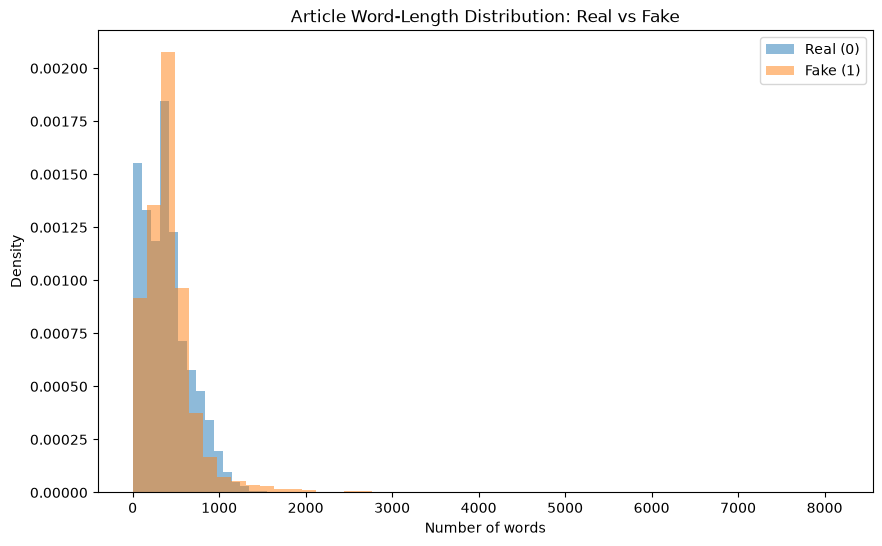

In [11]:
real_words = df[df['label'] == 0]['word_count']
fake_words = df[df['label'] == 1]['word_count']

plt.figure(figsize=(10, 6))

plt.hist(
    real_words,
    bins=50,
    alpha=0.5,
    label='Real (0)',
    density=True
)

plt.hist(
    fake_words,
    bins=50,
    alpha=0.5,
    label='Fake (1)',
    density=True
)

plt.xlabel('Number of words')
plt.ylabel('Density')
plt.title('Article Word-Length Distribution: Real vs Fake')

plt.legend()
plt.show()

In [12]:
word_stats = df.groupby('label')['word_count'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
)

word_stats

,count,mean,std,min,median,max
label,,,,,,
0,21417,395.594574,273.948006,4,369.0,5181
1,23481,437.930710,408.555516,2,378.0,8148


In [13]:
word_stats.index = ['Real (0)', 'Fake (1)']

word_stats

,count,mean,std,min,median,max
Real (0),21417,395.594574,273.948006,4,369.0,5181
Fake (1),23481,437.930710,408.555516,2,378.0,8148


<Figure size 800x600 with 0 Axes>

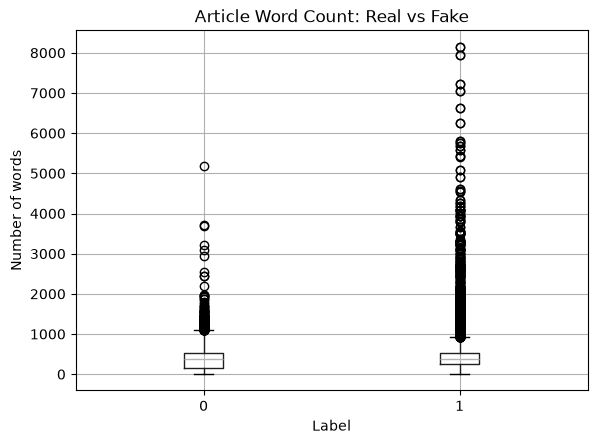

In [14]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column='word_count',
    by='label'
)

plt.xlabel('Label')
plt.ylabel('Number of words')
plt.title('Article Word Count: Real vs Fake')

plt.suptitle('')

plt.show()

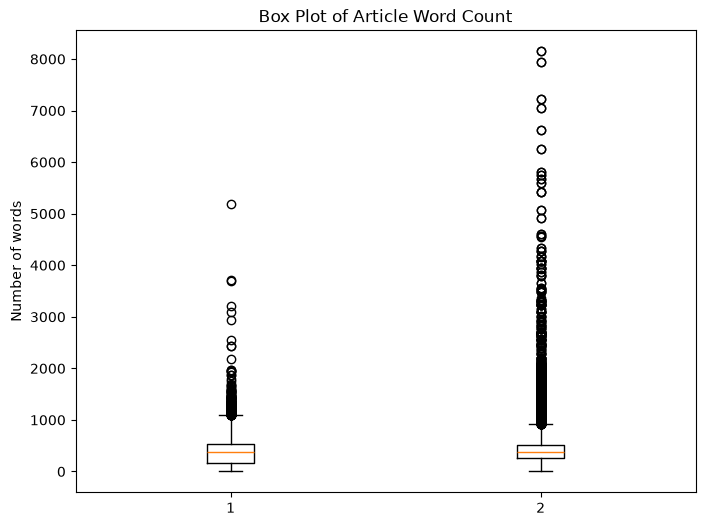

In [15]:
real_words = df[df['label'] == 0]['word_count']
fake_words = df[df['label'] == 1]['word_count']

plt.figure(figsize=(8, 6))

plt.boxplot(
    [real_words, fake_words],
    label=['Real (0)', 'Fake (1)'],
    showfliers=True
)

plt.ylabel('Number of words')
plt.title('Box Plot of Article Word Count')

plt.show()

In [16]:
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 216.0
Q3: 526.0
IQR: 310.0
Lower bound: -249.0
Upper bound: 991.0


In [17]:
outliers = df[
    (df['word_count'] < lower_bound) |
    (df['word_count'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 1674


In [18]:
short_articles = df[df['word_count'] >20]

print("Articles with fewer than 20 words:", len(short_articles))

Articles with fewer than 20 words: 44156


In [19]:
def tokenize(text):
    return re.findall(r'\b[a-zA-Z]+\b', text.lower())

df['tokens'] = df['content'].apply(tokenize)

df[['content', 'tokens']].head()

,content,tokens
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"[breaking, gop, chairman, grassley, has, had, ..."
1,Failed GOP Candidates Remembered In Hilarious...,"[failed, gop, candidates, remembered, in, hila..."
2,Mike Pence's New DC Neighbors Are HILARIOUSLY...,"[mike, pence, s, new, dc, neighbors, are, hila..."
3,California AG pledges to defend birth control ...,"[california, ag, pledges, to, defend, birth, c..."
4,AZ RANCHERS Living On US-Mexico Border Destroy...,"[az, ranchers, living, on, us, mexico, border,..."


In [20]:
plt.figure(figsize=(8, 6))

token_len = df["tokens"].apply(len)

bins = list(range(0, 6901, 100)) + [6922]

counts = pd.cut(
    token_len,
    bins=bins,
    right=False
).value_counts().sort_index()

pd.set_option('display.max_rows', None)

print(counts)

# dd.boxplot(
#     column='word_count',
#     by='label'
# )

# plt.xlabel('Label')
# plt.ylabel('Number of words')
# plt.title('Article Word Count: Real vs Fake')
# plt.suptitle('')
# plt.show()

tokens
[0, 100)        5159
[100, 200)      5254
[200, 300)      5389
[300, 400)      8560
[400, 500)      7681
[500, 600)      4254
[600, 700)      2782
[700, 800)      1849
[800, 900)      1440
[900, 1000)      845
[1000, 1100)     431
[1100, 1200)     329
[1200, 1300)     212
[1300, 1400)     137
[1400, 1500)      83
[1500, 1600)     100
[1600, 1700)      57
[1700, 1800)      32
[1800, 1900)      40
[1900, 2000)      29
[2000, 2100)      25
[2100, 2200)      20
[2200, 2300)       7
[2300, 2400)      10
[2400, 2500)      13
[2500, 2600)       4
[2600, 2700)      16
[2700, 2800)      16
[2800, 2900)       6
[2900, 3000)       7
[3000, 3100)       9
[3100, 3200)       7
[3200, 3300)       9
[3300, 3400)      10
[3400, 3500)       1
[3500, 3600)       7
[3600, 3700)       5
[3700, 3800)       3
[3800, 3900)       6
[3900, 4000)       5
[4000, 4100)       3
[4100, 4200)       5
[4200, 4300)       4
[4300, 4400)       3
[4400, 4500)       0
[4500, 4600)       0
[4600, 4700)       4
[4700,

<Figure size 800x600 with 0 Axes>

In [21]:
all_words = Counter()

for tokens in df['tokens']:
    all_words.update(tokens)

most_common_words = all_words.most_common(40000)

most_common_words

[('the', 1032882),
 ('to', 553882),
 ('of', 450096),
 ('a', 417751),
 ('and', 413335),
 ('in', 362196),
 ('s', 298687),
 ('that', 241100),
 ('on', 199217),
 ('for', 180983),
 ('is', 169986),
 ('trump', 148899),
 ('he', 135274),
 ('it', 134890),
 ('said', 133033),
 ('with', 121899),
 ('was', 116783),
 ('as', 107179),
 ('his', 98209),
 ('by', 97837),
 ('has', 89520),
 ('be', 85132),
 ('not', 83676),
 ('have', 83301),
 ('from', 82418),
 ('this', 80689),
 ('at', 77889),
 ('are', 73725),
 ('who', 71378),
 ('they', 68529),
 ('an', 68317),
 ('i', 63095),
 ('we', 62043),
 ('but', 61393),
 ('u', 59535),
 ('president', 57559),
 ('t', 56168),
 ('would', 55662),
 ('about', 52462),
 ('will', 51119),
 ('you', 48481),
 ('their', 47658),
 ('had', 46345),
 ('been', 42829),
 ('people', 42473),
 ('more', 40810),
 ('were', 40718),
 ('or', 40492),
 ('after', 39784),
 ('she', 38698),
 ('one', 38682),
 ('which', 38409),
 ('her', 37480),
 ('if', 36524),
 ('out', 35993),
 ('all', 35649),
 ('state', 35612),
 ('

In [22]:
common_words_df = pd.DataFrame(
    most_common_words,
    columns=['word', 'count']
)

common_words_df

,word,count
0,the,1032882
1,to,553882
2,of,450096
3,a,417751
4,and,413335
5,in,362196
6,s,298687
7,that,241100
8,on,199217
9,for,180983


In [23]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yosef\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
df['filtered_tokens'] = df['tokens'].apply(
    lambda words: [
        word for word in words
        if word not in stop_words
    ]
)

In [25]:
real_counter = Counter()

for tokens in df[df['label'] == 0]['filtered_tokens']:
    real_counter.update(tokens)

real_common = pd.DataFrame(
    real_counter.most_common(30),
    columns=['word', 'count']
)
print("common words in real articles -> label 0")
real_common

common words in real articles -> label 0


,word,count
0,said,99076
1,trump,60261
2,u,49276
3,would,31839
4,reuters,29112
5,president,28698
6,state,21691
7,government,19262
8,house,18089
9,new,17792


In [26]:
fake_counter = Counter()

for tokens in df[df['label'] == 1]['filtered_tokens']:
    fake_counter.update(tokens)

fake_common = pd.DataFrame(
    fake_counter.most_common(30),
    columns=['word', 'count']
)
print("common words in fake articles -> label 1")
fake_common

common words in fake articles -> label 1


,word,count
0,trump,88638
1,said,33957
2,president,28861
3,people,27085
4,one,25164
5,would,23823
6,obama,21379
7,clinton,20311
8,donald,18519
9,like,18491


In [27]:
def document_frequency(dataframe, label):
    counter = Counter()

    subset = dataframe[dataframe['label'] == label]

    for tokens in subset['filtered_tokens']:
        # set() means each word counts once per article
        counter.update(set(tokens))

    return counter


real_doc_freq = document_frequency(df, 0)
fake_doc_freq = document_frequency(df, 1)

In [28]:
real_total = (df['label'] == 0).sum()
fake_total = (df['label'] == 1).sum()

all_vocab = set(real_doc_freq) | set(fake_doc_freq)

word_analysis = []

for word in all_vocab:
    real_count = real_doc_freq.get(word, 0)
    fake_count = fake_doc_freq.get(word, 0)

    real_pct = real_count / real_total * 100
    fake_pct = fake_count / fake_total * 100

    gap = abs(real_pct - fake_pct)

    word_analysis.append({
        'word': word,
        'real_docs': real_count,
        'fake_docs': fake_count,
        'real_pct': real_pct,
        'fake_pct': fake_pct,
        'gap': gap
    })

word_analysis_df = pd.DataFrame(word_analysis)

word_analysis_df.head(30)

,word,real_docs,fake_docs,real_pct,fake_pct,gap
0,mochaccino,0,1,0.000000,0.004259,0.004259
1,gallups,0,1,0.000000,0.004259,0.004259
2,unsold,1,1,0.004669,0.004259,0.000410
3,minimis,1,1,0.004669,0.004259,0.000410
4,stuttered,0,6,0.000000,0.025553,0.025553
5,regale,0,1,0.000000,0.004259,0.004259
6,faceted,5,4,0.023346,0.017035,0.006311
7,ahler,0,2,0.000000,0.008518,0.008518
8,rad,1,1,0.004669,0.004259,0.000410
9,anxiously,9,12,0.042023,0.051105,0.009082


In [29]:
word_analysis_filtered = word_analysis_df[
    (word_analysis_df['real_docs'] + word_analysis_df['fake_docs']) >= 100
].copy()

In [30]:
fake_associated = word_analysis_filtered.sort_values(
    'fake_pct',
    ascending=False
)

fake_associated.head(30)

,word,real_docs,fake_docs,real_pct,fake_pct,gap
78198,trump,9615,13052,44.894243,55.585367,10.691124
60401,said,20060,12826,93.663912,54.622887,39.041025
79241,one,8074,12492,37.699024,53.200460,15.501436
105284,people,7864,11518,36.718495,49.052425,12.333931
67777,via,478,11198,2.231872,47.689621,45.457750
26668,would,12015,10892,56.100294,46.386440,9.713854
62119,president,13068,10680,61.016949,45.483582,15.533367
62407,video,623,10359,2.908904,44.116520,41.207616
65506,like,3436,10273,16.043330,43.750266,27.706936
91500,donald,9304,9214,43.442125,39.240237,4.201889


In [31]:
fake_leakage_candidates = word_analysis_filtered[
    word_analysis_filtered['fake_pct'] > word_analysis_filtered['real_pct']
].sort_values(
    'gap',
    ascending=False
)

fake_leakage_candidates.head(30)

,word,real_docs,fake_docs,real_pct,fake_pct,gap
67777,via,478,11198,2.231872,47.689621,45.457750
62407,video,623,10359,2.908904,44.116520,41.207616
2968,image,291,9021,1.358734,38.418296,37.059562
99766,featured,95,8109,0.443573,34.534304,34.090731
65506,like,3436,10273,16.043330,43.750266,27.706936
59944,watch,448,6266,2.091796,26.685405,24.593609
39343,even,3094,8609,14.446468,36.663686,22.217218
83373,com,174,4956,0.812439,21.106426,20.293988
54780,know,1779,6633,8.306486,28.248371,19.941886
26662,us,2008,6781,9.375730,28.878668,19.502938


In [32]:
real_leakage_candidates = word_analysis_filtered[
    word_analysis_filtered['real_pct'] > word_analysis_filtered['fake_pct']
].sort_values(
    'gap',
    ascending=False
)

real_leakage_candidates.head(30)

,word,real_docs,fake_docs,real_pct,fake_pct,gap
15612,reuters,21378,308,99.817902,1.311699,98.506203
16948,u,13949,4449,65.130504,18.947234,46.183270
60401,said,20060,12826,93.663912,54.622887,39.041025
86495,washington,8960,3305,41.835925,14.075210,27.760715
49904,minister,5108,594,23.850212,2.529705,21.320508
73509,government,8425,4349,39.337909,18.521358,20.816551
91688,wednesday,5593,1783,26.114769,7.593373,18.521395
94387,tuesday,5671,1990,26.478965,8.474937,18.004028
93762,told,9251,5921,43.194658,25.216132,17.978526
83563,thursday,5340,1738,24.933464,7.401729,17.531735


In [33]:
top_discriminative = word_analysis_filtered.sort_values(
    'gap',
    ascending=False
).head(50)

top_discriminative[
    [
        'word',
        'real_docs',
        'fake_docs',
        'real_pct',
        'fake_pct',
        'gap'
    ]
]

,word,real_docs,fake_docs,real_pct,fake_pct,gap
15612,reuters,21378,308,99.817902,1.311699,98.506203
16948,u,13949,4449,65.130504,18.947234,46.183270
67777,via,478,11198,2.231872,47.689621,45.457750
62407,video,623,10359,2.908904,44.116520,41.207616
60401,said,20060,12826,93.663912,54.622887,39.041025
2968,image,291,9021,1.358734,38.418296,37.059562
99766,featured,95,8109,0.443573,34.534304,34.090731
86495,washington,8960,3305,41.835925,14.075210,27.760715
65506,like,3436,10273,16.043330,43.750266,27.706936
59944,watch,448,6266,2.091796,26.685405,24.593609


In [34]:
suspicious_terms = [
    'reuters',
    'associated press',
    'ap news',
    'cnn',
    'bbc',
    'fox news',
    'new york times',
    'washington post',
    'guardian',
    'breitbart',
    'infowars'
]

for term in suspicious_terms:
    count = df['content'].str.lower().str.contains(
        term,
        regex=False
    ).sum()

    print(f"{term}: {count}")

reuters: 21700
associated press: 375
ap news: 48
cnn: 2849
bbc: 333
fox news: 2519
new york times: 1514
washington post: 1431
guardian: 442
breitbart: 1351
infowars: 158


In [35]:
url_pattern = r'https?://\S+|www\.\S+'

df['has_url'] = df['content'].str.contains(
    url_pattern,
    regex=True
)

print(df['has_url'].value_counts())

has_url
False    41501
True      3397
Name: count, dtype: int64


In [36]:
pd.crosstab(
    df['label'],
    df['has_url'],
    normalize='index'
) * 100

has_url,False,True
label,,
0,99.808563,0.191437
1,85.707593,14.292407


In [37]:
email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b'

df['has_email'] = df['content'].str.contains(
    email_pattern,
    regex=True
)

pd.crosstab(
    df['label'],
    df['has_email'],
    normalize='index'
) * 100

has_email,False,True
label,,
0,99.985992,0.014008
1,99.782803,0.217197


In [38]:
df.groupby('label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21417.0,395.594574,273.948006,4.0,159.0,369.0,534.0,5181.0
1,23481.0,437.930710,408.555516,2.0,254.0,378.0,521.0,8148.0


In [39]:
print("========== DATASET SUMMARY ==========")

print("Rows:", len(df))
print("Columns:", df.shape[1])

print("\nLabels:")
print(df['label'].value_counts())

print("\nLabel percentages:")
print(df['label'].value_counts(normalize=True) * 100)

# Don't use df.duplicated() because tokens columns contain lists
print("\nDuplicate content:", df['content'].duplicated().sum())

print(
    "Duplicate articles (content + label):",
    df.duplicated(subset=['content', 'label']).sum()
)

print("\nWord count:")
print(df['word_count'].describe())

print("\nMissing values:")
print(
    df[['title', 'text', 'content', 'label']]
    .isnull()
    .sum()
)

========== DATASET SUMMARY ==========
Rows: 44898
Columns: 9

Labels:
label
1    23481
0    21417
Name: count, dtype: int64

Label percentages:
label
1    52.298543
0    47.701457
Name: proportion, dtype: float64

Duplicate content: 5794
Duplicate articles (content + label): 5794

Word count:
count    44898.000000
mean       417.735757
std        351.480777
min          2.000000
25%        216.000000
50%        375.000000
75%        526.000000
max       8148.000000
Name: word_count, dtype: float64

Missing values:
title      0
text       0
content    0
label      0
dtype: int64


In [40]:

# ============================================================
# 04 — DATA LEAKAGE ANALYSIS
# ============================================================

import re
import pandas as pd

print("=" * 60)
print("DATA LEAKAGE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 04.1 Source / publisher markers
# ------------------------------------------------------------

source_terms = [
    "reuters",
    "associated press",
    "ap news",
    "bbc",
    "cnn",
    "new york times",
    "washington post"
]

print("\nSource marker distribution:")
print("-" * 60)

for term in source_terms:

    mask = df["content"].str.lower().str.contains(
        term,
        regex=False,
        na=False
    )

    total = mask.sum()

    if total > 0:
        distribution = (
            df.loc[mask, "label"]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )

        print(f"\n'{term}'")
        print(f"Total occurrences: {total:,}")
        print(distribution)

# ------------------------------------------------------------
# 04.2 Suspicious formatting/source terms
# ------------------------------------------------------------

suspicious_terms = [
    "via",
    "video",
    "image",
    "featured",
    "getty",
    "youtube",
    "facebook",
    "twitter"
]

print("\n\nFormatting / source marker analysis:")
print("-" * 60)

for term in suspicious_terms:

    mask = df["content"].str.lower().str.contains(
        term,
        regex=False,
        na=False
    )

    total = mask.sum()

    if total > 0:

        fake_percentage = (
            df.loc[mask, "label"].mean() * 100
        )

        print(
            f"{term:12s} "
            f"count={total:6,} | "
            f"fake={fake_percentage:6.2f}%"
        )

# ------------------------------------------------------------
# 04.3 URL leakage
# ------------------------------------------------------------

url_pattern = r"https?://\S+|www\.\S+"

df["has_url"] = df["content"].str.contains(
    url_pattern,
    regex=True,
    na=False
)

print("\nURL distribution:")
print(
    pd.crosstab(
        df["label"],
        df["has_url"],
        normalize="index"
    ).mul(100).round(2)
)

# ------------------------------------------------------------
# 04.4 Email leakage
# ------------------------------------------------------------

email_pattern = (
    r"\b[A-Za-z0-9._%+-]+"
    r"@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
)

df["has_email"] = df["content"].str.contains(
    email_pattern,
    regex=True,
    na=False
)

print("\nEmail distribution:")
print(
    pd.crosstab(
        df["label"],
        df["has_email"],
        normalize="index"
    ).mul(100).round(2)
)

# ------------------------------------------------------------
# 04.5 Explicit warning
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LEAKAGE WARNING")
print("=" * 60)

print(
    """
Some words, publishers, formatting patterns, and source markers
are highly associated with a particular ISOT label.

A classifier may therefore learn dataset/source artifacts rather
than genuine characteristics of fake versus real news.

For this reason, the main experiment should be accompanied by
a leakage-controlled experiment.
"""
)



DATA LEAKAGE ANALYSIS

Source marker distribution:
------------------------------------------------------------

'reuters'
Total occurrences: 21,700
label
0    98.52
1     1.48
Name: proportion, dtype: float64

'associated press'
Total occurrences: 375
label
1    76.27
0    23.73
Name: proportion, dtype: float64

'ap news'
Total occurrences: 48
label
1    52.08
0    47.92
Name: proportion, dtype: float64

'bbc'
Total occurrences: 333
label
1    57.06
0    42.94
Name: proportion, dtype: float64

'cnn'
Total occurrences: 2,849
label
1    78.2
0    21.8
Name: proportion, dtype: float64

'new york times'
Total occurrences: 1,514
label
1    71.47
0    28.53
Name: proportion, dtype: float64

'washington post'
Total occurrences: 1,431
label
1    74.77
0    25.23
Name: proportion, dtype: float64


Formatting / source marker analysis:
------------------------------------------------------------
via          count=12,709 | fake= 91.16%
video        count=11,310 | fake= 93.42%
image        count=

In [41]:
# ===================================================
# 05 — DUPLICATE REMOVAL
# ============================================================

print("=" * 60)
print("DUPLICATE REMOVAL")
print("=" * 60)

before_count = len(df)

# ------------------------------------------------------------
# 05.1 Check duplicate content
# ------------------------------------------------------------

duplicate_mask = df["content"].duplicated(keep=False)

print(f"Original articles: {before_count:,}")
print(
    f"Articles involved in duplicate groups: "
    f"{duplicate_mask.sum():,}"
)

print(
    f"Unique duplicate contents: "
    f"{df.loc[duplicate_mask, 'content'].nunique():,}"
)

# ------------------------------------------------------------
# 05.2 Check whether duplicates have conflicting labels
# ------------------------------------------------------------

duplicate_label_check = (
    df.groupby("content")["label"]
    .nunique()
)

conflicting_duplicates = (
    duplicate_label_check > 1
).sum()

print(
    f"\nDuplicate content groups with conflicting labels: "
    f"{conflicting_duplicates:,}"
)

# ------------------------------------------------------------
# 05.3 Remove duplicate content
# ------------------------------------------------------------

df = (
    df
    .drop_duplicates(
        subset=["content"],
        keep="first"
    )
    .reset_index(drop=True)
)

after_count = len(df)

print("\nAfter duplicate removal:")
print(f"Articles: {after_count:,}")
print(f"Removed: {before_count - after_count:,}")

print("\nNew label distribution:")
print(df["label"].value_counts().sort_index())

print("\nNew label percentages:")
print(
    df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# 05.4 Verify no duplicate content remains
# ------------------------------------------------------------

remaining_duplicates = df["content"].duplicated().sum()

print(
    f"\nRemaining duplicate contents: "
    f"{remaining_duplicates}"
)

assert remaining_duplicates == 0

print("\n✓ Duplicate removal completed successfully.")



DUPLICATE REMOVAL
Original articles: 44,898
Articles involved in duplicate groups: 11,100
Unique duplicate contents: 5,306

Duplicate content groups with conflicting labels: 0

After duplicate removal:
Articles: 39,104
Removed: 5,794

New label distribution:
label
0    21196
1    17908
Name: count, dtype: int64

New label percentages:
label
0    54.2
1    45.8
Name: proportion, dtype: float64

Remaining duplicate contents: 0

✓ Duplicate removal completed successfully.
